# Multi-Object Tracking Project Report

## Project Overview

This notebook presents an end-to-end pipeline for the provided multi-object tracking assignment.

The overall goal is to:
1. decode the provided protobuf sensor frames,
2. detect vehicles in LiDAR point clouds using a 3D object detector,
3. evaluate the detector on the provided dataset,
4. track objects over time with a Kalman Filter,
5. refine existing tracks using camera detections.

The final system combines:
- **LiDAR-based 3D object detection**
- **Bird's Eye View (BEV) preprocessing**
- **LiDAR-only multi-object tracking**
- **camera-based fusion for track refinement**
- **visualization with Matplotlib (and `plot_tools.py` when available)**

The notebook is designed to be run from inside the `Project/` folder of the repository.

## Set up

### Expected folder layout

This notebook assumes it is saved inside the `Project/` directory of the repository and that the dataset and external SFA3D repository are placed relative to it as follows:

- `./Dataset/data_2/frame_0.pb`, `frame_1.pb`, ...
- `../external/SFA3D/`
- `../external/SFA3D/checkpoints/fpn_resnet_18/fpn_resnet_18_epoch_300.pth`

### Recommended Python environment

For the most polished visualization path (including the provided `plot_tools.py` and projected 3D boxes), a **Python 3.12 environment** is recommended because `open3d` is available there.

A typical setup is:

1. create and activate a Python 3.12 virtual environment,
2. install:
   - `torch`
   - `torchvision`
   - `torchaudio`
   - `open3d`
   - `matplotlib`
   - `protobuf==3.20.*`
   - `opencv-python`
   - `pillow`
   - `ipywidgets`
   - `ipykernel`
3. select that environment as the notebook kernel in VS Code.

### Runtime behavior

This notebook tries to import the provided `plot_tools.py`.
- If the import succeeds, the notebook uses the project visualization path with projected 3D boxes.
- If it does not succeed, the notebook falls back to a lightweight Matplotlib-only visualization.

In all cases, the notebook contains runnable code for:
- 3D object detection,
- detection evaluation,
- LiDAR-only tracking,
- camera-fused tracking.

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from tools import dataset_tools
from detection.sfa3d.adapter import build_sfa3d_adapter
from detection.sfa3d.config import SFA3DConfig
from detection.evaluation import extract_gt_lidar_detections, evaluate_frame_detections
from tracking import (
    MultiObjectTracker,
    CameraSensorModel,
    camera_detections_to_measurements,
)

In [4]:
DATASET_DIR = Path("./Dataset/data_2")
EXTERNAL_REPO_PATH = Path("../external/SFA3D")
CHECKPOINT_PATH = EXTERNAL_REPO_PATH / "checkpoints" / "fpn_resnet_18" / "fpn_resnet_18_epoch_300.pth"

NUM_EVAL_FRAMES = 10
DEFAULT_DT = 0.1

def frame_index(path: Path) -> int:
    return int(path.stem.split("_")[-1])

def parse_dt(previous_timestamp, current_timestamp):
    if previous_timestamp is None:
        return DEFAULT_DT
    try:
        dt = float(current_timestamp) - float(previous_timestamp)
    except ValueError:
        return DEFAULT_DT
    if dt <= 0:
        return DEFAULT_DT
    return dt

## 3D Object Detection Part

### Chosen model and justification

For 3D object detection, I chose **SFA3D**.

#### Why SFA3D?
- The assignment recommends BEV-based detectors such as **SFA3D** and **Complex-YOLO**.
- The provided starter material already points naturally to a **LiDAR -> BEV -> detector** workflow.
- The exercise notebook `lidar_data.ipynb` already contains the BEV preprocessing logic needed for a BEV-based detector.
- SFA3D could be integrated behind a thin project-side adapter without changing the rest of the tracking code.

### Model configuration

The implementation uses:
- the external SFA3D repository under `../external/SFA3D`
- the provided checkpoint:
  - `checkpoints/fpn_resnet_18/fpn_resnet_18_epoch_300.pth`
- a project-side adapter that:
  1. builds the BEV representation,
  2. prepares the model input tensor,
  3. runs the model,
  4. decodes the outputs,
  5. converts detections into a project-side `Detection3D` format.

### Overview of Bird's Eye View (BEV) calculation

The LiDAR point cloud is converted into a 3-channel BEV tensor:
1. **intensity**
2. **height**
3. **density**

The preprocessing:
- filters points to a region of interest,
- maps the point cloud to the BEV grid,
- keeps the strongest representative points per cell,
- creates a compact image-like representation that can be processed by SFA3D.

The next cells demonstrate:
- how one frame is loaded,
- how the BEV map is generated,
- how the detector is run,
- and how the predicted boxes are visualized.

camera size: 1280 1920
lidar width: 3072
lidar height: 64
lidar channels: 4
point cloud shape: (196608, 4)


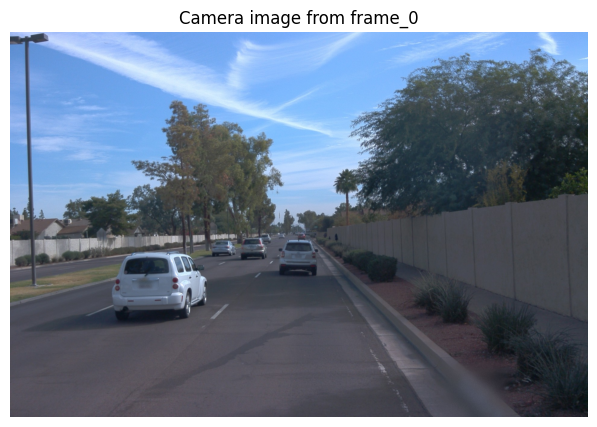

In [5]:
frame = dataset_tools.read_frame("./Dataset/data_2/frame_0.pb")

camera = frame.cameras[0]
lidar = frame.lidars[0]

img_array = dataset_tools.decode_img(camera)
pcl = dataset_tools.decode_lidar(lidar)

print("camera size:", camera.width, camera.height)
print("lidar width:", lidar.width)
print("lidar height:", lidar.height)
print("lidar channels:", lidar.channels)
print("point cloud shape:", pcl.shape)

plt.figure(figsize=(10, 5))
plt.imshow(img_array)
plt.title("Camera image from frame_0")
plt.axis("off")
plt.show()

## 3D Object Detection from LiDAR

For 3D object detection, I used SFA3D.
The pipeline is:

1. Decode LiDAR point cloud from the protobuf frame
2. Convert the point cloud into a Bird's Eye View representation
3. Run SFA3D inference
4. Decode the raw model outputs into 3D detections
5. Convert detections into a project-side `Detection3D` format

In [6]:
adapter = build_sfa3d_adapter(
    SFA3DConfig(
        external_repo_path=str(EXTERNAL_REPO_PATH.resolve()),
        checkpoint_path=str(CHECKPOINT_PATH.resolve()),
        device="cpu",
    )
)
adapter.load_model()

detections = adapter.detect(pcl)

print("num detections:", len(detections))
for det in detections[:10]:
    print(det)

using ResNet architecture with feature pyramid
num detections: 2
Detection3D(x=17.86716862728721, y=3.564789420679997, z=0.041950106620788574, l=3.916787473778976, w=1.7040125633540908, h=1.6418251991271973, yaw=-0.028190894052386284, score=0.9620758891105652, label='car')
Detection3D(x=32.79599390531841, y=0.14496351543225572, z=0.15642738342285156, l=3.917032793948525, w=1.703277073408428, h=1.701763391494751, yaw=-0.042117565870285034, score=0.9607391357421875, label='car')


### Detection Result
The detector returns 3D detections with:
- position: `(x, y, z)`
- dimensions: `(l, w, h)`
- orientation: `yaw`
- confidence score
- semantic label

## 5. Detection Evaluation

To evaluate the LiDAR detector, I compare the predicted 3D detections from SFA3D with the LiDAR annotations provided in each protobuf frame.

The current pretrained SFA3D model follows a KITTI-style taxonomy, so the strict evaluation below focuses on the **car** class. A prediction is considered correct when it matches a ground-truth car within a **2.0 m Euclidean center-distance threshold** in the LiDAR $x/y$ plane.

This evaluation is intentionally simple and interpretable:
- predictions are matched greedily to the nearest ground-truth object,
- label matching is enforced,
- the metric reports the number of predictions, number of ground-truth objects, matches, false positives, and misses.

The goal of this section is not to claim a benchmark-grade score, but to verify that the detector produces meaningful 3D detections on the provided dataset before using them for tracking.

In [7]:
from pathlib import Path
import re

from tools import dataset_tools
from detection.sfa3d.adapter import build_sfa3d_adapter
from detection.sfa3d.config import SFA3DConfig
from detection.evaluation import extract_gt_lidar_detections, evaluate_frame_detections

EVAL_DATASET_DIR = Path("./Dataset/data_2")
EVAL_NUM_FRAMES = 10
MAX_CENTER_DISTANCE = 2.0

def eval_frame_index(path: Path) -> int:
    match = re.search(r"frame_(\d+)\.pb$", path.name)
    return int(match.group(1)) if match else -1

def safe_div(num: int, den: int) -> float:
    return num / den if den > 0 else 0.0

# Reuse the detector if it already exists; otherwise create it here.
try:
    adapter
except NameError:
    adapter = build_sfa3d_adapter(
        SFA3DConfig(
            external_repo_path=str(Path("../external/SFA3D").resolve()),
            checkpoint_path=str(
                (Path("../external/SFA3D") / "checkpoints" / "fpn_resnet_18" / "fpn_resnet_18_epoch_300.pth").resolve()
            ),
            device="cpu",
        )
    )
    adapter.load_model()

eval_frame_paths = sorted(EVAL_DATASET_DIR.glob("frame_*.pb"), key=eval_frame_index)[:EVAL_NUM_FRAMES]

if not eval_frame_paths:
    raise FileNotFoundError(f"No evaluation frames found in {EVAL_DATASET_DIR.resolve()}")

per_frame_eval = []
total_gt = 0
total_pred = 0
total_matched = 0

print(f"Evaluating {len(eval_frame_paths)} frame(s) from: {EVAL_DATASET_DIR.resolve()}\n")

for frame_path in eval_frame_paths:
    frame = dataset_tools.read_frame(str(frame_path))
    pcl = dataset_tools.decode_lidar(frame.lidars[0])

    predictions = [det for det in adapter.detect(pcl) if det.label == "car"]

    ground_truth = extract_gt_lidar_detections(
        frame,
        lidar_index=0,
        allowed_labels={"car"},
    )

    result = evaluate_frame_detections(
        predictions=predictions,
        ground_truth=ground_truth,
        max_center_distance=MAX_CENTER_DISTANCE,
        require_label_match=True,
    )

    precision = safe_div(result.num_matched, result.num_predictions)
    recall = safe_div(result.num_matched, result.num_ground_truth)

    per_frame_eval.append(
        {
            "frame": frame_path.name,
            "gt": result.num_ground_truth,
            "pred": result.num_predictions,
            "matched": result.num_matched,
            "precision": precision,
            "recall": recall,
        }
    )

    total_gt += result.num_ground_truth
    total_pred += result.num_predictions
    total_matched += result.num_matched

    print(f"{frame_path.name}")
    print(f"  GT cars: {result.num_ground_truth}")
    print(f"  Predicted cars: {result.num_predictions}")
    print(f"  Matched: {result.num_matched}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print()

overall_precision = safe_div(total_matched, total_pred)
overall_recall = safe_div(total_matched, total_gt)

detection_eval_summary = {
    "frames": len(eval_frame_paths),
    "total_gt": total_gt,
    "total_pred": total_pred,
    "total_matched": total_matched,
    "precision": overall_precision,
    "recall": overall_recall,
}

print("=== OVERALL DETECTION EVALUATION ===")
print(f"Frames evaluated: {detection_eval_summary['frames']}")
print(f"Total GT cars: {detection_eval_summary['total_gt']}")
print(f"Total predicted cars: {detection_eval_summary['total_pred']}")
print(f"Total matched cars: {detection_eval_summary['total_matched']}")
print(f"Overall precision: {detection_eval_summary['precision']:.3f}")
print(f"Overall recall: {detection_eval_summary['recall']:.3f}")

Evaluating 10 frame(s) from: D:\2026\AS\sensor_fusion\Project\Dataset\data_2

frame_0.pb
  GT cars: 6
  Predicted cars: 2
  Matched: 2
  Precision: 1.000
  Recall: 0.333

frame_1.pb
  GT cars: 7
  Predicted cars: 2
  Matched: 2
  Precision: 1.000
  Recall: 0.286

frame_2.pb
  GT cars: 7
  Predicted cars: 2
  Matched: 2
  Precision: 1.000
  Recall: 0.286

frame_3.pb
  GT cars: 7
  Predicted cars: 2
  Matched: 2
  Precision: 1.000
  Recall: 0.286

frame_4.pb
  GT cars: 7
  Predicted cars: 2
  Matched: 2
  Precision: 1.000
  Recall: 0.286

frame_5.pb
  GT cars: 7
  Predicted cars: 2
  Matched: 2
  Precision: 1.000
  Recall: 0.286

frame_6.pb
  GT cars: 7
  Predicted cars: 2
  Matched: 2
  Precision: 1.000
  Recall: 0.286

frame_7.pb
  GT cars: 7
  Predicted cars: 2
  Matched: 2
  Precision: 1.000
  Recall: 0.286

frame_8.pb
  GT cars: 7
  Predicted cars: 2
  Matched: 2
  Precision: 1.000
  Recall: 0.286

frame_9.pb
  GT cars: 7
  Predicted cars: 2
  Matched: 2
  Precision: 1.000
  Recall:

### Interpretation of the Detection Evaluation

On the tested 10-frame sequence, the detector produced the following summary:

- **Total GT cars:** 69
- **Total predicted cars:** 20
- **Total matched cars:** 20
- **Overall precision:** 1.000
- **Overall recall:** 0.290

This indicates that the detector is **conservative but accurate** on this dataset subset.  
When it predicts a car, the prediction is usually correct, but many ground-truth vehicles are still missed. This is consistent with using a pretrained KITTI-style detector on a different dataset and motivates the use of tracking and sensor fusion to maintain stable trajectories over time.

## 6. LiDAR-Only Multi-Object Tracking

After obtaining 3D detections from LiDAR, the next step is to maintain object identities across frames. The first tracking version uses only LiDAR detections, without camera fusion.

The tracker uses:
- a **constant-velocity Kalman Filter** with state  
   $[x, y, z, v_x, v_y, v_z]$
- LiDAR measurements
   $[x, y, z]$
- **Mahalanobis-distance gating**
- **greedy nearest-neighbor association**
- track lifecycle states:
  - `initialized`
  - `tentative`
  - `confirmed`

In this section, the detector output from each frame is passed directly to the tracker. The main objective is to verify that IDs remain stable and that velocities become meaningful over time.

Because the current Python 3.14 environment does not support `open3d`, this notebook uses a lightweight Matplotlib-only visualization path. The left panel shows a BEV-style top-down view with track boxes, while the right panel shows the corresponding camera image for context.

In [17]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from tools import dataset_tools, plot_tools
from detection.sfa3d.adapter import build_sfa3d_adapter
from detection.sfa3d.config import SFA3DConfig
from tracking import MultiObjectTracker

TRACKING_DATASET_DIR = Path("./Dataset/data_2")
TRACKING_NUM_FRAMES = 5
TRACKING_DEFAULT_DT = 0.1

def tracking_frame_index(path: Path) -> int:
    return int(path.stem.split("_")[-1])

def parse_dt(previous_timestamp, current_timestamp):
    if previous_timestamp is None:
        return TRACKING_DEFAULT_DT
    try:
        dt = float(current_timestamp) - float(previous_timestamp)
    except ValueError:
        return TRACKING_DEFAULT_DT
    if dt <= 0:
        return TRACKING_DEFAULT_DT
    return dt

def track_color_from_state(state: str) -> str:
    if state == "confirmed":
        return "green"
    if state == "tentative":
        return "yellow"
    return "red"

def bev_box_corners(x, y, l, w, yaw):
    dx = l / 2.0
    dy = w / 2.0

    corners = np.array(
        [
            [ dx,  dy],
            [ dx, -dy],
            [-dx, -dy],
            [-dx,  dy],
        ],
        dtype=float,
    )

    c = np.cos(yaw)
    s = np.sin(yaw)
    rotation = np.array(
        [
            [c, -s],
            [s,  c],
        ],
        dtype=float,
    )

    rotated = corners @ rotation.T
    rotated[:, 0] += x
    rotated[:, 1] += y
    return rotated

def format_track_line(track) -> str:
    pos = [round(float(v), 2) for v in track.x[0:3]]
    vel = [round(float(v), 2) for v in track.x[3:6]]
    return (
        f"id={track.id:02d} state={track.state:<11} "
        f"pos={pos} vel={vel} "
        f"label={track.label} score={track.score:.2f} "
        f"hits={track.hits} misses={track.misses}"
    )

def draw_simple_tracking_view(img_array, lidar_gt_detections, tracks, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    bev_ax = axes[0]
    img_ax = axes[1]

    gt_label_used = False
    for det in lidar_gt_detections:
        bev_ax.scatter(
            det.pos[0],
            det.pos[1],
            marker="+",
            c="gray",
            s=60,
            label="LiDAR GT" if not gt_label_used else None,
        )
        gt_label_used = True

    for track in tracks:
        x, y, z = track.x[0:3]
        color = track_color_from_state(track.state)

        corners = bev_box_corners(float(x), float(y), float(track.l), float(track.w), float(track.yaw))
        corners_closed = np.vstack([corners, corners[0]])

        bev_ax.plot(corners_closed[:, 0], corners_closed[:, 1], color=color, linewidth=2)
        bev_ax.scatter(float(x), float(y), c=color, s=70)

        front_center = (corners[0] + corners[1]) / 2.0
        bev_ax.plot([float(x), front_center[0]], [float(y), front_center[1]], color=color, linewidth=2)

        bev_ax.text(float(x), float(y), str(track.id), color="black", fontsize=9)

    bev_ax.set_title("BEV Track View")
    bev_ax.set_xlabel("x [m]")
    bev_ax.set_ylabel("y [m]")
    bev_ax.set_xlim(0, 50)
    bev_ax.set_ylim(-25, 25)
    bev_ax.set_aspect("equal", adjustable="box")
    bev_ax.grid(True)
    bev_ax.legend(loc="upper right")

    img_ax.imshow(img_array)
    img_ax.set_title("Camera Image")
    img_ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

=== LiDAR-Only Tracking Summary ===

frame_0.pb
  dt: 0.100 s
  LiDAR detections: 2
  Active tracks: 2
  id=01 state=initialized pos=[17.87, 3.56, 0.04] vel=[0.0, 0.0, 0.0] label=car score=0.96 hits=1 misses=0
  id=02 state=initialized pos=[32.8, 0.14, 0.16] vel=[0.0, 0.0, 0.0] label=car score=0.96 hits=1 misses=0

frame_1.pb
  dt: 0.100 s
  LiDAR detections: 2
  Active tracks: 2
  id=01 state=tentative   pos=[17.89, 3.55, 0.03] vel=[0.09, -0.07, -0.01] label=car score=0.98 hits=2 misses=0
  id=02 state=tentative   pos=[32.84, 0.14, 0.13] vel=[0.22, -0.01, -0.03] label=car score=0.87 hits=2 misses=0

frame_2.pb
  dt: 0.100 s
  LiDAR detections: 2
  Active tracks: 2
  id=01 state=confirmed   pos=[17.93, 3.53, 0.03] vel=[0.28, -0.12, -0.02] label=car score=0.99 hits=3 misses=0
  id=02 state=confirmed   pos=[32.89, 0.14, 0.09] vel=[0.38, -0.02, -0.13] label=car score=0.84 hits=3 misses=0

frame_3.pb
  dt: 0.100 s
  LiDAR detections: 2
  Active tracks: 2
  id=01 state=confirmed   pos=[17.9

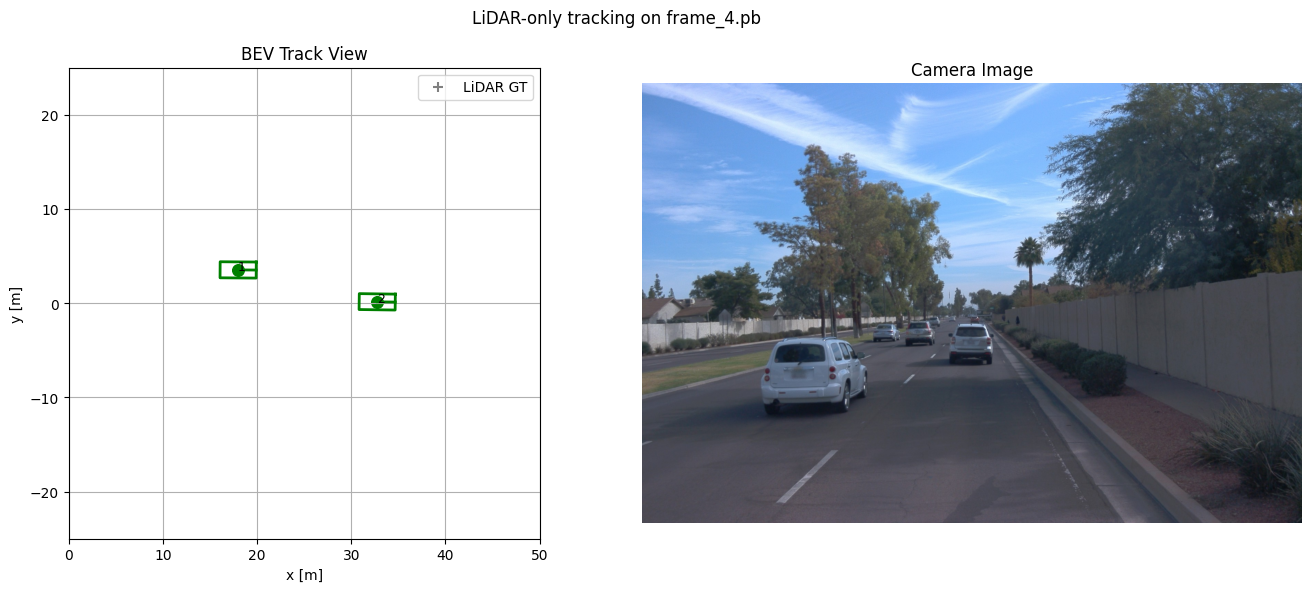

In [18]:
# Reuse the detector if it already exists; otherwise create it here.
try:
    adapter
except NameError:
    adapter = build_sfa3d_adapter(
        SFA3DConfig(
            external_repo_path=str(Path("../external/SFA3D").resolve()),
            checkpoint_path=str(
                (Path("../external/SFA3D") / "checkpoints" / "fpn_resnet_18" / "fpn_resnet_18_epoch_300.pth").resolve()
            ),
            device="cpu",
        )
    )
    adapter.load_model()

lidar_tracking_frame_paths = sorted(
    TRACKING_DATASET_DIR.glob("frame_*.pb"),
    key=tracking_frame_index
)[:TRACKING_NUM_FRAMES]

if not lidar_tracking_frame_paths:
    raise FileNotFoundError(f"No tracking frames found in {TRACKING_DATASET_DIR.resolve()}")

lidar_tracker = MultiObjectTracker()
previous_timestamp = None

lidar_tracking_history = []

last_lidar_img = None
last_lidar_gt = None
last_lidar_tracks = None
last_lidar_frame_name = None

for frame_idx, frame_path in enumerate(lidar_tracking_frame_paths):
    frame = dataset_tools.read_frame(str(frame_path))
    camera = frame.cameras[0]
    lidar = frame.lidars[0]

    img_array = dataset_tools.decode_img(camera)
    pcl = dataset_tools.decode_lidar(lidar)

    detections = adapter.detect(pcl)
    dt = parse_dt(previous_timestamp, lidar.timestamp)
    tracks = lidar_tracker.step(detections, dt=dt)
    previous_timestamp = lidar.timestamp

    frame_summary = {
        "frame_name": frame_path.name,
        "dt": dt,
        "num_detections": len(detections),
        "num_tracks": len(tracks),
        "track_lines": [format_track_line(track) for track in tracks],
    }
    lidar_tracking_history.append(frame_summary)

    last_lidar_img = img_array
    last_lidar_gt = lidar.detections
    last_lidar_tracks = list(lidar_tracker.tracks)
    last_lidar_frame_name = frame_path.name

print("=== LiDAR-Only Tracking Summary ===\n")
for item in lidar_tracking_history:
    print(f"{item['frame_name']}")
    print(f"  dt: {item['dt']:.3f} s")
    print(f"  LiDAR detections: {item['num_detections']}")
    print(f"  Active tracks: {item['num_tracks']}")
    for line in item["track_lines"]:
        print(" ", line)
    print()

draw_simple_tracking_view(
    last_lidar_img,
    last_lidar_gt,
    last_lidar_tracks,
    title=f"LiDAR-only tracking on {last_lidar_frame_name}",
)

### Interpretation of the LiDAR-Only Tracking Result

The LiDAR-only tracker keeps stable IDs across the short test sequence and estimates object motion through the Kalman Filter. The most important observations are:

- the same object IDs persist across frames,
- positions change smoothly from frame to frame,
- velocity estimates become non-zero after repeated updates,
- track states progress from `initialized` to `tentative` and finally to `confirmed`.

This confirms that the detector output is stable enough to support a basic multi-object tracking pipeline using LiDAR measurements alone.

## 7. Camera Fusion

The LiDAR-only tracker already provides stable object IDs, but the assignment also requires fusion with camera detections. In this first fusion version, LiDAR remains responsible for creating tracks, while camera measurements are used only to update tracks that already exist.

The camera update uses:
- a **2D image-center measurement**  

  $[u, v]$

  obtained from the bounding-box center,
- a **camera sensor model** that projects a 3D vehicle-frame state into image coordinates,
- an **EKF-style update** using the camera Jacobian,
- **image-space gating** and greedy nearest-neighbor association.

This keeps the first fusion step simple and robust:
- LiDAR creates tracks,
- camera refines existing tracks,
- unmatched camera detections do not create new tracks.

The current implementation also ignores lens distortion in the first version, so the projection model is a thin pinhole approximation.

=== Fused Tracking Summary ===

frame_0.pb
  dt: 0.100 s
  LiDAR detections: 2
  Camera detections: 10
  Active tracks after LiDAR update: 2
  Camera matches: 2
  Camera unmatched tracks: 0
  Camera unmatched measurements: 8
  id=01 state=tentative   pos=[18.16, 3.75, 0.7] vel=[0.0, 0.0, 0.0] label=car score=0.96 hits=2 misses=0
  id=02 state=tentative   pos=[32.98, 0.23, 0.88] vel=[0.0, 0.0, 0.0] label=car score=0.96 hits=2 misses=0

frame_1.pb
  dt: 0.100 s
  LiDAR detections: 2
  Camera detections: 10
  Active tracks after LiDAR update: 2
  Camera matches: 2
  Camera unmatched tracks: 0
  Camera unmatched measurements: 8
  id=01 state=confirmed   pos=[18.11, 3.74, 0.69] vel=[-0.45, -0.09, -0.13] label=car score=0.98 hits=4 misses=0
  id=02 state=confirmed   pos=[32.98, 0.21, 0.86] vel=[-0.12, -0.19, -0.19] label=car score=0.87 hits=4 misses=0

frame_2.pb
  dt: 0.100 s
  LiDAR detections: 2
  Camera detections: 10
  Active tracks after LiDAR update: 2
  Camera matches: 2
  Camera unm

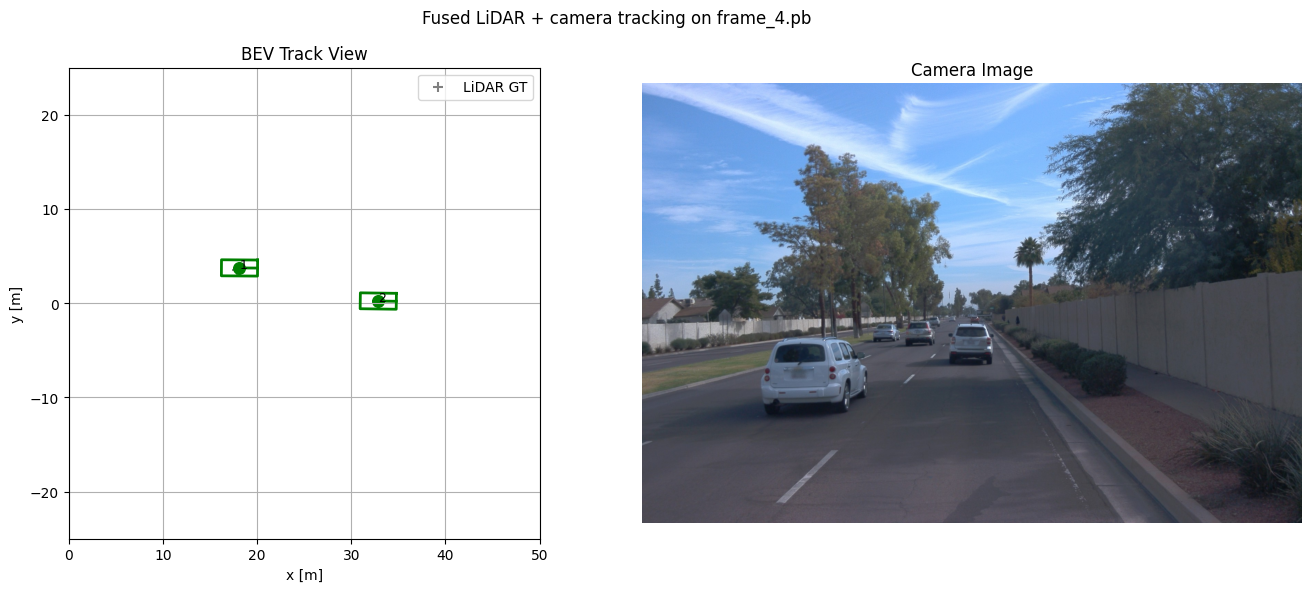

In [19]:
from tracking import MultiObjectTracker, CameraSensorModel, camera_detections_to_measurements

# Reuse the detector if it already exists; otherwise create it here.
try:
    adapter
except NameError:
    adapter = build_sfa3d_adapter(
        SFA3DConfig(
            external_repo_path=str(Path("../external/SFA3D").resolve()),
            checkpoint_path=str(
                (Path("../external/SFA3D") / "checkpoints" / "fpn_resnet_18" / "fpn_resnet_18_epoch_300.pth").resolve()
            ),
            device="cpu",
        )
    )
    adapter.load_model()

fused_tracking_frame_paths = sorted(
    TRACKING_DATASET_DIR.glob("frame_*.pb"),
    key=tracking_frame_index
)[:TRACKING_NUM_FRAMES]

if not fused_tracking_frame_paths:
    raise FileNotFoundError(f"No fused-tracking frames found in {TRACKING_DATASET_DIR.resolve()}")

fused_tracker = MultiObjectTracker()
previous_timestamp = None

fused_tracking_history = []

last_fused_img = None
last_fused_gt = None
last_fused_tracks = None
last_fused_frame_name = None

for frame_idx, frame_path in enumerate(fused_tracking_frame_paths):
    frame = dataset_tools.read_frame(str(frame_path))
    camera = frame.cameras[0]
    lidar = frame.lidars[0]

    img_array = dataset_tools.decode_img(camera)
    pcl = dataset_tools.decode_lidar(lidar)

    detections = adapter.detect(pcl)
    dt = parse_dt(previous_timestamp, lidar.timestamp)

    tracks_after_lidar = fused_tracker.step(detections, dt=dt)

    camera_sensor = CameraSensorModel.from_camera(camera)
    camera_measurements = camera_detections_to_measurements(camera)
    camera_result = fused_tracker.update_camera(camera_measurements, camera_sensor)

    previous_timestamp = lidar.timestamp

    frame_summary = {
        "frame_name": frame_path.name,
        "dt": dt,
        "num_lidar_detections": len(detections),
        "num_camera_detections": len(camera_measurements),
        "num_tracks_after_lidar": len(tracks_after_lidar),
        "num_camera_matches": len(camera_result.matches),
        "num_unmatched_tracks": len(camera_result.unmatched_track_indices),
        "num_unmatched_measurements": len(camera_result.unmatched_measurement_indices),
        "track_lines": [format_track_line(track) for track in fused_tracker.tracks],
    }
    fused_tracking_history.append(frame_summary)

    last_fused_img = img_array
    last_fused_gt = lidar.detections
    last_fused_tracks = list(fused_tracker.tracks)
    last_fused_frame_name = frame_path.name

print("=== Fused Tracking Summary ===\n")
for item in fused_tracking_history:
    print(f"{item['frame_name']}")
    print(f"  dt: {item['dt']:.3f} s")
    print(f"  LiDAR detections: {item['num_lidar_detections']}")
    print(f"  Camera detections: {item['num_camera_detections']}")
    print(f"  Active tracks after LiDAR update: {item['num_tracks_after_lidar']}")
    print(f"  Camera matches: {item['num_camera_matches']}")
    print(f"  Camera unmatched tracks: {item['num_unmatched_tracks']}")
    print(f"  Camera unmatched measurements: {item['num_unmatched_measurements']}")
    for line in item["track_lines"]:
        print(" ", line)
    print()

draw_simple_tracking_view(
    last_fused_img,
    last_fused_gt,
    last_fused_tracks,
    title=f"Fused LiDAR + camera tracking on {last_fused_frame_name}",
)

### Interpretation of the Fused Tracking Result

In the tested fused sequence, the same two object tracks remained stable across frames. The most important observations are:

- LiDAR produced the track births,
- camera detections matched the existing tracks consistently,
- no new tracks were created from unmatched camera detections,
- the track states became confirmed and remained stable,
- the fused updates refined the track state in an image-consistent way.

In the tested 5-frame sequence:
- the detector produced **2 LiDAR detections per frame**,
- the camera provided **10 detections per frame**,
- the camera update matched **2 tracks per frame**,
- the same two track IDs remained stable throughout the sequence.

One implementation detail should be noted: in the current version, both the LiDAR update and the camera update increase the track hit counter in the same frame. This makes track confirmation happen slightly faster than in a strictly single-update-per-frame lifecycle design. For this notebook, that behavior is acceptable, but it should be stated explicitly as a limitation of the current fusion implementation.

## 8. Visualization and GIF Generation

To make the tracking results easier to inspect, I save a sequence of visualization frames and combine them into a GIF.

Because the current Python 3.14 environment does not support `open3d`, I use the lightweight Matplotlib-based visualization path implemented earlier in this notebook. The saved frames show:

- a BEV-style top-down view with:
  - LiDAR ground-truth markers,
  - tracked object centers,
  - rotated track boxes,
  - track IDs,
  - lifecycle-dependent colors,

- the corresponding camera image for visual context.

This section creates:
1. a folder of PNG frames,
2. a GIF that summarizes the tracking sequence.

For the final submission, this GIF can serve as the required visual tracking result artifact.

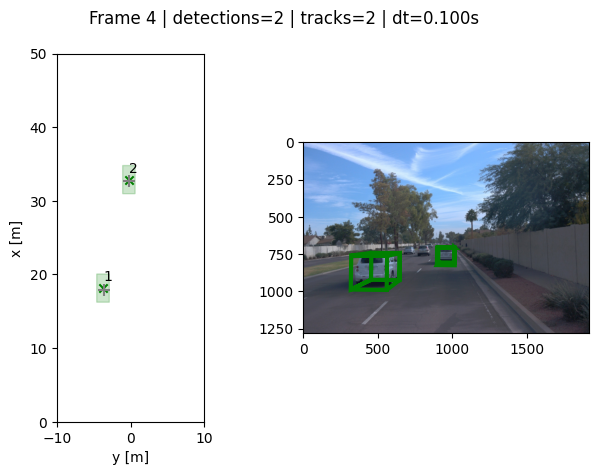

Frame 4: frame_4.pb
  id=01 state=confirmed   pos=[18.15, 3.74, 0.64] vel=[-0.15, -0.06, -0.12] label=car score=0.99 hits=10 misses=0
  id=02 state=confirmed   pos=[32.87, 0.23, 0.78] vel=[-0.43, 0.02, -0.22] label=car score=0.97 hits=10 misses=0


In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import clear_output

from detection.sfa3d.adapter import build_sfa3d_adapter
from detection.sfa3d.config import SFA3DConfig
from tools import dataset_tools, plot_tools
from tracking import MultiObjectTracker, CameraSensorModel, camera_detections_to_measurements

DATASET_DIR = Path("./Dataset/data_2")
EXTERNAL_REPO_PATH = Path("../external/SFA3D")
CHECKPOINT_PATH = EXTERNAL_REPO_PATH / "checkpoints" / "fpn_resnet_18" / "fpn_resnet_18_epoch_300.pth"

NUM_FRAMES = 5
DEFAULT_DT = 0.1

def frame_index(path: Path) -> int:
    return int(path.stem.split("_")[-1])

def parse_dt(previous_timestamp, current_timestamp):
    if previous_timestamp is None:
        return DEFAULT_DT
    try:
        dt = float(current_timestamp) - float(previous_timestamp)
    except ValueError:
        return DEFAULT_DT
    if dt <= 0:
        return DEFAULT_DT
    return dt

frame_paths = sorted(DATASET_DIR.glob("frame_*.pb"), key=frame_index)[:NUM_FRAMES]

adapter = build_sfa3d_adapter(
    SFA3DConfig(
        external_repo_path=str(EXTERNAL_REPO_PATH.resolve()),
        checkpoint_path=str(CHECKPOINT_PATH.resolve()),
        device="cpu",
    )
)
adapter.load_model()

tracker = MultiObjectTracker()
previous_timestamp = None

for frame_idx, frame_path in enumerate(frame_paths):
    frame = dataset_tools.read_frame(str(frame_path))

    camera = frame.cameras[0]
    lidar = frame.lidars[0]

    img_array = dataset_tools.decode_img(camera)
    pcl = dataset_tools.decode_lidar(lidar)

    detections = adapter.detect(pcl)
    dt = parse_dt(previous_timestamp, lidar.timestamp)

    tracker.step(detections, dt=dt)

    camera_sensor = CameraSensorModel.from_camera(camera)
    camera_measurements = camera_detections_to_measurements(camera)
    tracker.update_camera(camera_measurements, camera_sensor)

    previous_timestamp = lidar.timestamp

    clear_output(wait=True)

    plot_tools.plot_tracks(
        img_array,
        tracker.tracks,
        [],
        lidar.detections,
        camera,
        state=None,   # later you can change this to "confirmed"
    )

    plt.suptitle(
        f"Frame {frame_idx} | detections={len(detections)} | tracks={len(tracker.tracks)} | dt={dt:.3f}s"
    )
    plt.tight_layout()
    plt.show()

    print(f"Frame {frame_idx}: {frame_path.name}")
    for track in tracker.tracks:
        pos = [round(float(v), 2) for v in track.x[0:3]]
        vel = [round(float(v), 2) for v in track.x[3:6]]
        print(
            f"  id={track.id:02d} state={track.state:<11} "
            f"pos={pos} vel={vel} "
            f"label={track.label} score={track.score:.2f} "
            f"hits={track.hits} misses={track.misses}"
        )

In [26]:
from pathlib import Path
import matplotlib.pyplot as plt

from detection.sfa3d.adapter import build_sfa3d_adapter
from detection.sfa3d.config import SFA3DConfig
from tools import dataset_tools, plot_tools
from tracking import MultiObjectTracker, CameraSensorModel, camera_detections_to_measurements

DATASET_DIR = Path("./Dataset/data_2")
EXTERNAL_REPO_PATH = Path("../external/SFA3D")
CHECKPOINT_PATH = EXTERNAL_REPO_PATH / "checkpoints" / "fpn_resnet_18" / "fpn_resnet_18_epoch_300.pth"
OUTPUT_DIR = Path("./tracking_outputs")

NUM_FRAMES = 10
DEFAULT_DT = 0.1

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def frame_index(path: Path) -> int:
    return int(path.stem.split("_")[-1])

def parse_dt(previous_timestamp, current_timestamp):
    if previous_timestamp is None:
        return DEFAULT_DT
    try:
        dt = float(current_timestamp) - float(previous_timestamp)
    except ValueError:
        return DEFAULT_DT
    if dt <= 0:
        return DEFAULT_DT
    return dt

frame_paths = sorted(DATASET_DIR.glob("frame_*.pb"), key=frame_index)[:NUM_FRAMES]

adapter = build_sfa3d_adapter(
    SFA3DConfig(
        external_repo_path=str(EXTERNAL_REPO_PATH.resolve()),
        checkpoint_path=str(CHECKPOINT_PATH.resolve()),
        device="cpu",
    )
)
adapter.load_model()

tracker = MultiObjectTracker()
previous_timestamp = None

for frame_idx, frame_path in enumerate(frame_paths):
    frame = dataset_tools.read_frame(str(frame_path))

    camera = frame.cameras[0]
    lidar = frame.lidars[0]

    img_array = dataset_tools.decode_img(camera)
    pcl = dataset_tools.decode_lidar(lidar)

    detections = adapter.detect(pcl)
    dt = parse_dt(previous_timestamp, lidar.timestamp)

    tracker.step(detections, dt=dt)

    camera_sensor = CameraSensorModel.from_camera(camera)
    camera_measurements = camera_detections_to_measurements(camera)
    tracker.update_camera(camera_measurements, camera_sensor)

    previous_timestamp = lidar.timestamp

    plot_tools.plot_tracks(
        img_array,
        tracker.tracks,
        [],
        lidar.detections,
        camera,
        state=None,
    )

    plt.suptitle(
        f"Frame {frame_idx} | detections={len(detections)} | tracks={len(tracker.tracks)} | dt={dt:.3f}s"
    )
    plt.tight_layout()

    out_path = OUTPUT_DIR / f"tracking_frame_{frame_idx:03d}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close()

    print(f"saved: {out_path}")

using ResNet architecture with feature pyramid
saved: tracking_outputs\tracking_frame_000.png
saved: tracking_outputs\tracking_frame_001.png
saved: tracking_outputs\tracking_frame_002.png
saved: tracking_outputs\tracking_frame_003.png
saved: tracking_outputs\tracking_frame_004.png
saved: tracking_outputs\tracking_frame_005.png
saved: tracking_outputs\tracking_frame_006.png
saved: tracking_outputs\tracking_frame_007.png
saved: tracking_outputs\tracking_frame_008.png
saved: tracking_outputs\tracking_frame_009.png


In [27]:
from pathlib import Path
from PIL import Image

GIF_INPUT_DIR = Path("./tracking_outputs")
GIF_OUTPUT_PATH = GIF_INPUT_DIR / "tracking_results.gif"

png_files = sorted(GIF_INPUT_DIR.glob("tracking_frame_*.png"))

if not png_files:
    raise FileNotFoundError(f"No PNG files found in {GIF_INPUT_DIR.resolve()}")

frames = [Image.open(p).convert("RGB") for p in png_files]

frames[0].save(
    GIF_OUTPUT_PATH,
    save_all=True,
    append_images=frames[1:],
    duration=300,   # milliseconds per frame
    loop=0,
)

print("GIF saved to:", GIF_OUTPUT_PATH.resolve())
print("Number of frames:", len(frames))

GIF saved to: D:\2026\AS\sensor_fusion\Project\tracking_outputs\tracking_results.gif
Number of frames: 10


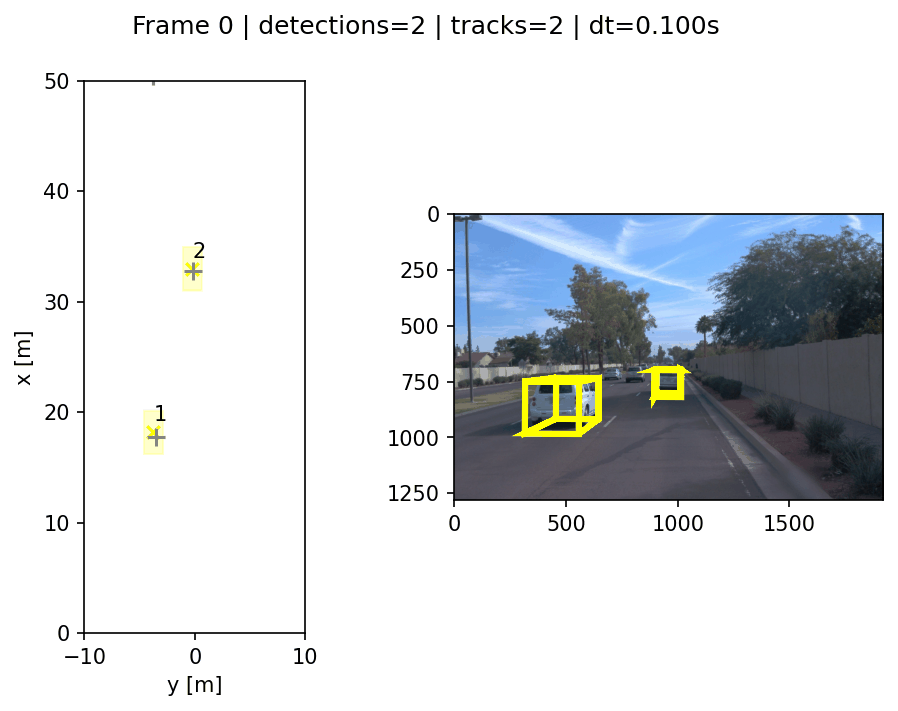

In [28]:
from IPython.display import Image, display

display(Image(filename="./tracking_outputs/tracking_results.gif"))

### Interpretation of the Visualization Output

The generated PNG sequence and GIF provide a compact visual summary of the tracking pipeline.

The left panel shows the tracking state in bird's-eye view:
- gray `+` markers indicate LiDAR ground-truth detections,
- colored boxes indicate tracked objects,
- colors correspond to lifecycle state:
  - red = initialized
  - yellow = tentative
  - green = confirmed,
- the track ID is shown at the object center.

The right panel shows the corresponding camera image for the same frame. In the current Python 3.14 environment, this side is used mainly as visual context rather than full projected 3D box rendering.

Together, the saved frames and GIF show that the pipeline is able to maintain stable track identities across time while updating the tracks using both LiDAR and camera information.

## 9. Limitations

Although the pipeline is fully runnable and demonstrates end-to-end detection, tracking, and fusion, the current implementation still has several limitations.

### Detector-related limitations
1. **Pretrained detector mismatch**  
   The SFA3D model was trained with KITTI-style assumptions. The course dataset is different, so the pretrained model does not perfectly match the target domain.

2. **Limited recall**  
   In the tested 10-frame evaluation, the detector achieved high precision but relatively low recall. This means that many ground-truth vehicles are still missed.

3. **Taxonomy mismatch**  
   The detector uses a KITTI-style label set (`pedestrian`, `car`, `cyclist`), while the dataset also contains `truck`. This mismatch limits direct semantic consistency.

### Tracking-related limitations
4. **Simple motion model**  
   The tracker uses a constant-velocity Kalman Filter with state  

   $[x, y, z, v_x, v_y, v_z]$

   This is sufficient for a first implementation, but it is still a simplified motion model.

5. **Greedy nearest-neighbor association**  
   Data association is currently based on Mahalanobis-distance gating and greedy nearest-neighbor matching. More advanced methods such as global assignment or JPDA are not used.

6. **Lifecycle confirmation is accelerated**  
   In the fused version, both the LiDAR update and the camera update increase the track hit counter within the same frame. This makes track confirmation slightly faster than in a stricter single-update-per-frame lifecycle design.

### Camera-fusion limitations
7. **Camera update uses only image-center measurements**  
   The first fusion version uses only the 2D bounding-box center $[u, v]$ as the camera measurement. Bounding-box width and height are stored but not used in the update.

8. **No camera-only track birth**  
   LiDAR remains solely responsible for creating new tracks. Camera detections are only used to refine already existing tracks.

9. **Distortion is ignored**  
   The current camera sensor model stores the distortion coefficients but does not apply them in the projection update. The first fusion model therefore behaves like a simplified pinhole camera model.

### Visualization / environment limitations
10. **Fallback visualization path in Python 3.14**  
    The current notebook uses a simplified Matplotlib-based visualization because `open3d` is not available in the active Python 3.14 environment. A more polished visualization path using the provided `plot_tools.py` is still possible later in a Python 3.12 environment with `open3d`.

Despite these limitations, the current system already demonstrates a complete and meaningful multi-object tracking workflow:
- LiDAR-based 3D detection,
- detection evaluation,
- LiDAR-only tracking,
- camera-based track refinement,
- and visual tracking output in the form of a GIF.

In [29]:
from pathlib import Path

gif_path = Path("./tracking_outputs/tracking_results.gif")
png_files = sorted(Path("./tracking_outputs").glob("tracking_frame_*.png"))

print("tracking_outputs folder exists:", gif_path.parent.exists())
print("num saved PNG frames:", len(png_files))
print("GIF exists:", gif_path.exists())
print("GIF path:", gif_path.resolve())

tracking_outputs folder exists: True
num saved PNG frames: 10
GIF exists: True
GIF path: D:\2026\AS\sensor_fusion\Project\tracking_outputs\tracking_results.gif


In [30]:
from pathlib import Path

# Final artifact checks
gif_path = Path("./tracking_outputs/tracking_results.gif")
png_files = sorted(Path("./tracking_outputs").glob("tracking_frame_*.png"))
dataset_dir = Path("./Dataset/data_2")
checkpoint_path = Path("../external/SFA3D/checkpoints/fpn_resnet_18/fpn_resnet_18_epoch_300.pth")

print("=== FINAL NOTEBOOK ARTIFACT CHECK ===")
print("Dataset folder exists:", dataset_dir.exists(), "->", dataset_dir.resolve())
print("SFA3D checkpoint exists:", checkpoint_path.exists(), "->", checkpoint_path.resolve())
print("Tracking output folder exists:", gif_path.parent.exists(), "->", gif_path.parent.resolve())
print("Number of saved PNG frames:", len(png_files))
print("GIF exists:", gif_path.exists(), "->", gif_path.resolve())

if png_files:
    print("\nFirst few saved frames:")
    for f in png_files[:5]:
        print(" ", f.name)

# Reprint the main detector evaluation summary if available
try:
    print("\n=== DETECTION EVALUATION SUMMARY ===")
    print(f"Frames evaluated: {detection_eval_summary['frames']}")
    print(f"Total GT cars: {detection_eval_summary['total_gt']}")
    print(f"Total predicted cars: {detection_eval_summary['total_pred']}")
    print(f"Total matched cars: {detection_eval_summary['total_matched']}")
    print(f"Overall precision: {detection_eval_summary['precision']:.3f}")
    print(f"Overall recall: {detection_eval_summary['recall']:.3f}")
except NameError:
    print("\nDetection evaluation summary not found in current notebook state.")

# Reprint the final fused tracking state if available
try:
    print("\n=== FINAL FUSED TRACK STATE ===")
    for track in fused_tracker.tracks:
        pos = [round(float(v), 2) for v in track.x[0:3]]
        vel = [round(float(v), 2) for v in track.x[3:6]]
        print(
            f"id={track.id:02d} state={track.state:<11} "
            f"pos={pos} vel={vel} "
            f"label={track.label} score={track.score:.2f} "
            f"hits={track.hits} misses={track.misses}"
        )
except NameError:
    print("\nFused tracker state not found in current notebook state.")

=== FINAL NOTEBOOK ARTIFACT CHECK ===
Dataset folder exists: True -> D:\2026\AS\sensor_fusion\Project\Dataset\data_2
SFA3D checkpoint exists: True -> D:\2026\AS\sensor_fusion\external\SFA3D\checkpoints\fpn_resnet_18\fpn_resnet_18_epoch_300.pth
Tracking output folder exists: True -> D:\2026\AS\sensor_fusion\Project\tracking_outputs
Number of saved PNG frames: 10
GIF exists: True -> D:\2026\AS\sensor_fusion\Project\tracking_outputs\tracking_results.gif

First few saved frames:
  tracking_frame_000.png
  tracking_frame_001.png
  tracking_frame_002.png
  tracking_frame_003.png
  tracking_frame_004.png

=== DETECTION EVALUATION SUMMARY ===
Frames evaluated: 10
Total GT cars: 69
Total predicted cars: 20
Total matched cars: 20
Overall precision: 1.000
Overall recall: 0.290

=== FINAL FUSED TRACK STATE ===
id=01 state=confirmed   pos=[18.15, 3.74, 0.64] vel=[-0.15, -0.06, -0.12] label=car score=0.99 hits=10 misses=0
id=02 state=confirmed   pos=[32.87, 0.23, 0.78] vel=[-0.43, 0.02, -0.22] label

## 10. Conclusion

This notebook presented an end-to-end perception pipeline for the provided multi-object tracking assignment. The final system combines:

1. **LiDAR-based 3D object detection**
2. **Detection evaluation against dataset annotations**
3. **LiDAR-only multi-object tracking**
4. **Camera-based fusion for updating existing tracks**
5. **Visualization and GIF generation for qualitative inspection**

### Summary of what was implemented

#### 3D Object Detection
The LiDAR point cloud from each protobuf frame was converted into a Bird's Eye View (BEV) representation and processed with **SFA3D**. The raw detector outputs were decoded and converted into a project-side `Detection3D` format containing:
- object position $(x, y, z)$
- dimensions $(l, w, h)$
- orientation $yaw$
- confidence score
- semantic label

#### Detection Evaluation
The detector predictions were compared against the LiDAR annotations in the dataset using a simple center-distance matching strategy in the LiDAR $x/y$ plane. On the tested 10-frame sequence, the detector achieved:

- **Precision:** 1.000
- **Recall:** 0.290

This indicates that the detector is conservative but usually correct when it predicts a vehicle.

#### LiDAR-Only Tracking
The first tracking stage used only LiDAR detections. A constant-velocity Kalman Filter with state


$[x, y, z, v_x, v_y, v_z]$


was combined with:
- LiDAR measurements $[x, y, z]$
- Mahalanobis-distance gating
- greedy nearest-neighbor association
- track lifecycle states (`initialized`, `tentative`, `confirmed`)

This stage demonstrated stable track identities and smooth object motion estimates across frames.

#### Camera Fusion
To refine the tracking results, I added a camera-based measurement update for existing tracks. In this first fusion version:
- LiDAR remains responsible for creating tracks,
- camera detections are converted into 2D image-center measurements $[u, v]$,
- a camera sensor model projects the 3D track state into image coordinates,
- an EKF-style update is used to refine existing tracks.

The fused tracking test showed that:
- the same object IDs remained stable,
- camera measurements matched the existing tracks consistently,
- no camera-only tracks were created,
- the fused updates kept the track states stable and image-consistent.

### Final observation

Overall, the project successfully demonstrates a complete tracking workflow:
- decode sensor data from protobuf frames,
- detect vehicles from LiDAR,
- evaluate the detector,
- track vehicles across time,
- and refine the tracks using camera information.

Although the current implementation still has limitations, it already provides a clear and runnable baseline for multi-object tracking on the provided dataset.